In [3]:
from numpy import sin, cos, pi, exp, mean, absolute, angle, conj # Sentrale matematiske funksjoner
from numpy.fft import fft, ifft             # DFT og IDFT
import numpy as np                          # Importer funksjonalitet fra numpy biblioteket med prefiks "np"
import matplotlib.pyplot as plt             # Importer pyplot modulen i matplotlib med prefiks "plt"
from scipy.io import wavfile                # Lydfil I/O
from IPython.display import Audio           # Audio widget for embedded lydavspilling
import jupyterthemes

%matplotlib notebook

In [2]:
# Last inn sampleverdier og samplingsfrekvens
fs, data = wavfile.read(r'C:\Users\ASAP\Google Drive\Ntnu\Signalbehandling\Sig_Projekt\forelesningsopptak.wav') 
# Separer de to lydsporene, og konverter datatype fra int16 til flyttallsverdier mellom -1.0 og 1.0
xn1 = data.T[0]/0x8000
xn2 = data.T[1]/0x8000

print(fs)

# Lytt til lydsporet 'xn1'
Audio(xn1, rate=fs)

16000


In [3]:
Audio(xn2, rate=fs)

<IPython.core.display.Javascript object>


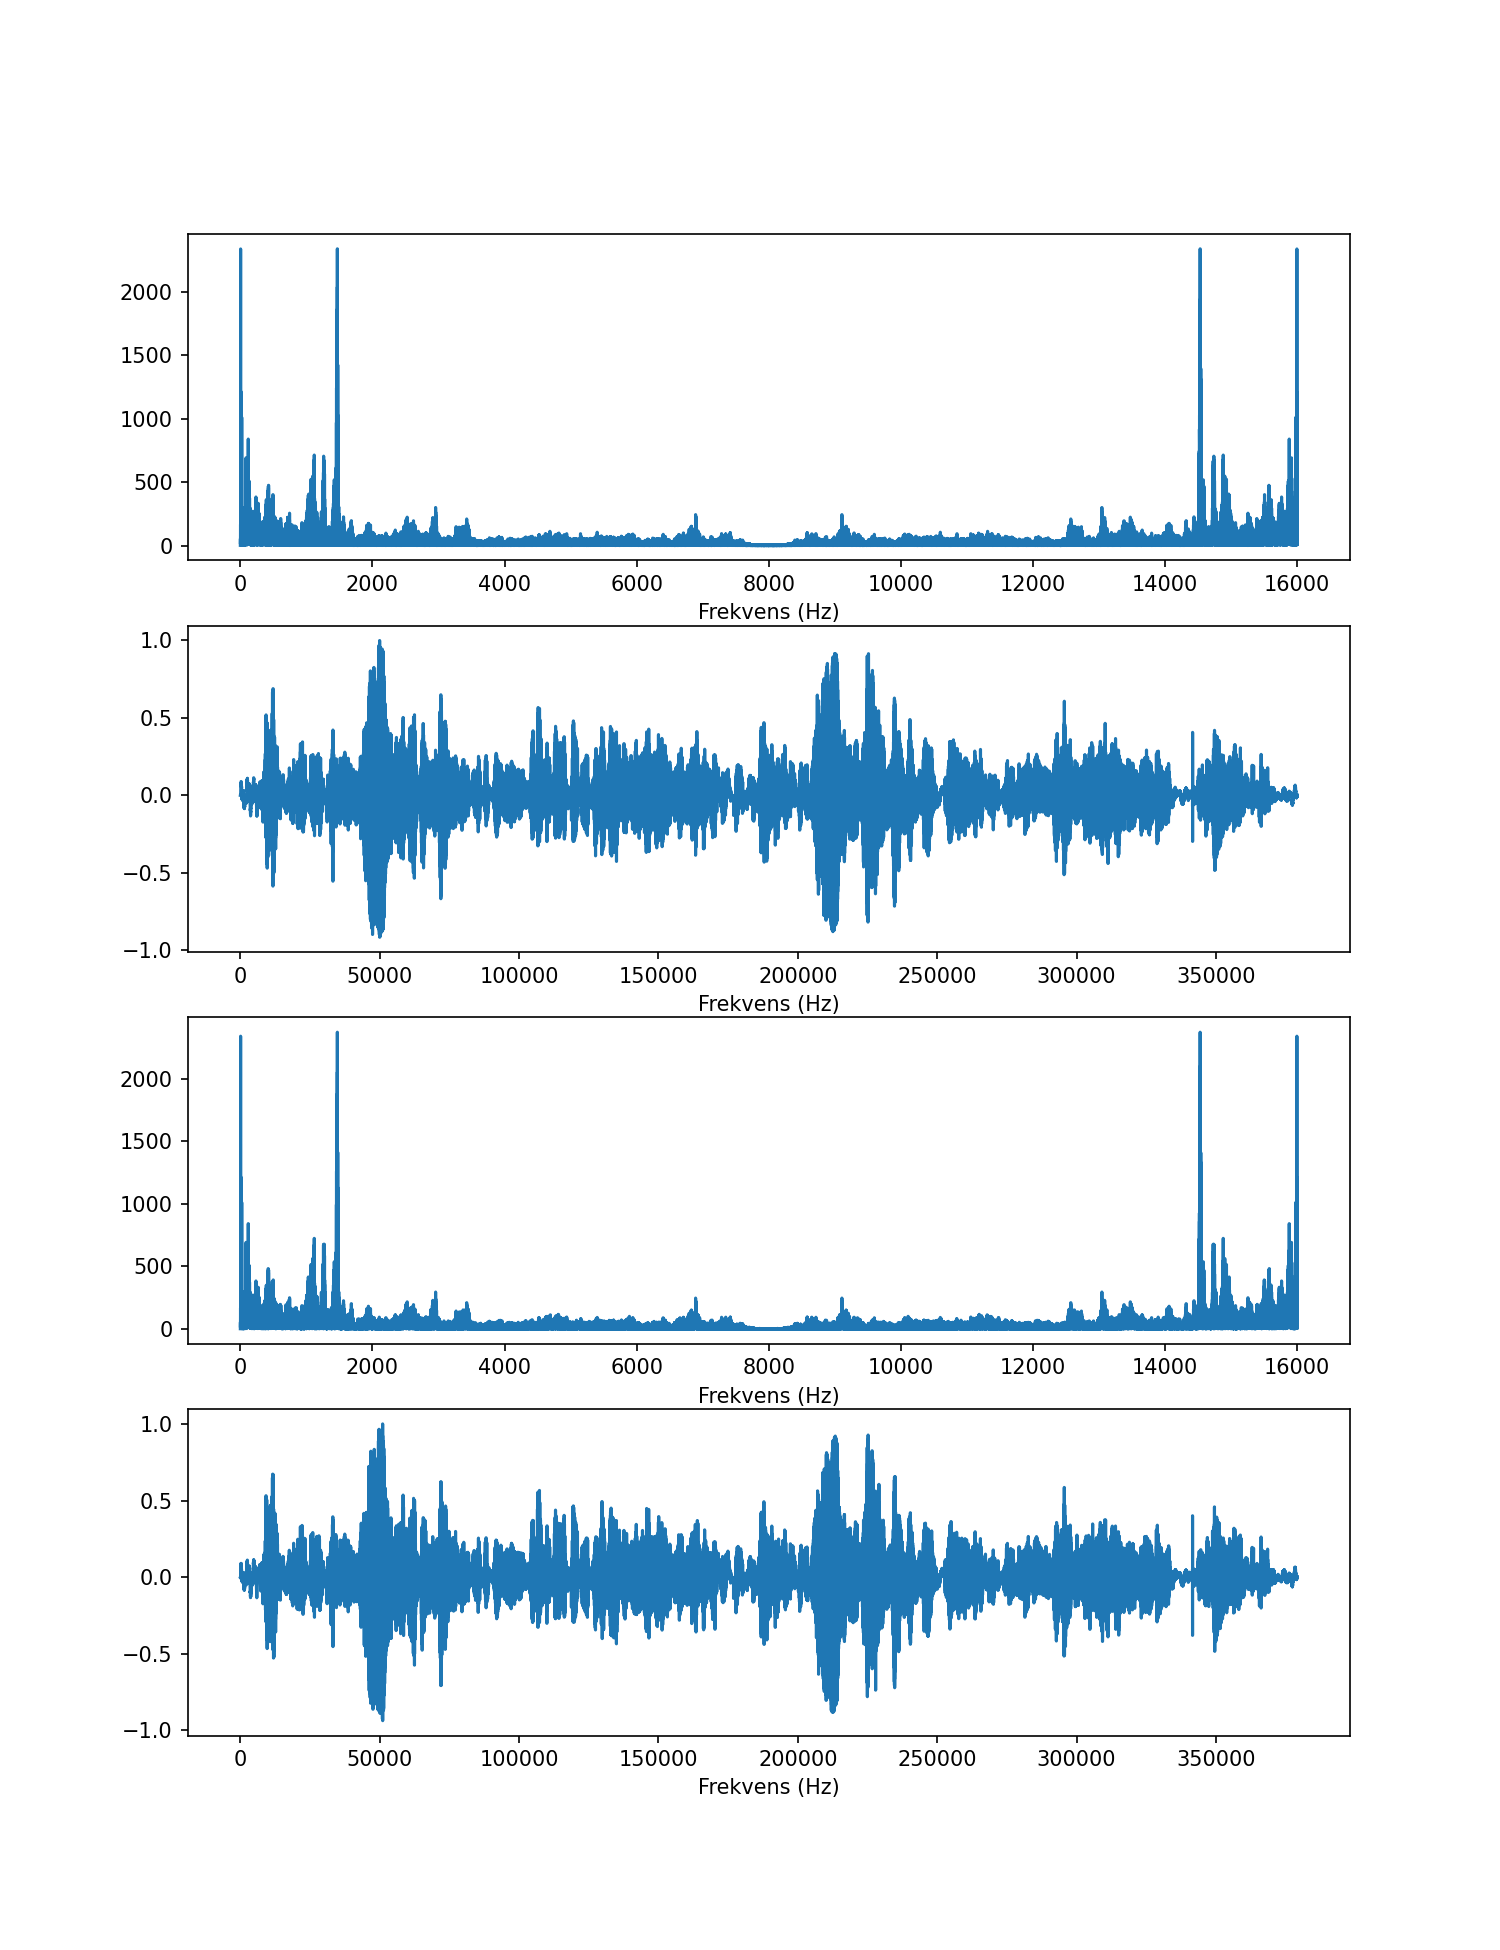

Text(0.5, 0, 'Frekvens (Hz)')

In [74]:
k_1 = np.arange(len(xn1))
Xk_1 = fft(xn1)
N_1 = len(Xk_1)

k_2 = np.arange(len(xn2))
Xk_2 = fft(xn2)
N_2 = len(Xk_2)

plt.close(1)
plt.figure(1, figsize=(10,13))
plt.subplot(4,1,1)
plt.plot(k_1/N_1*fs, np.absolute(Xk_1))
plt.xlabel("Frekvens (Hz)")

plt.subplot(4,1,2)
plt.plot(k_1, xn1)
plt.xlabel("Frekvens (Hz)")

plt.subplot(4,1,3)
plt.plot(k_2/N_2*fs, np.absolute(Xk_2))
plt.xlabel("Frekvens (Hz)")

plt.subplot(4,1,4)
plt.plot(k_2, xn2)
plt.xlabel("Frekvens (Hz)")

<IPython.core.display.Javascript object>


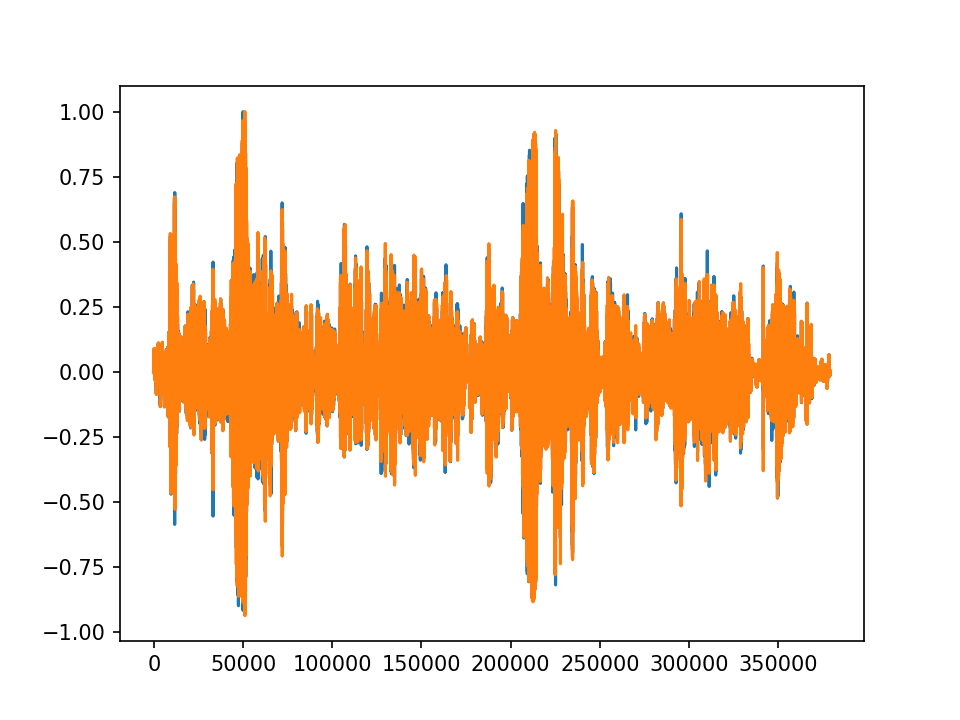

In [5]:
fig, ax = plt.subplots()
ax.plot(k_1, xn1, label='xn1')
ax.plot(k_2, xn2, label='xn2')

<IPython.core.display.Javascript object>


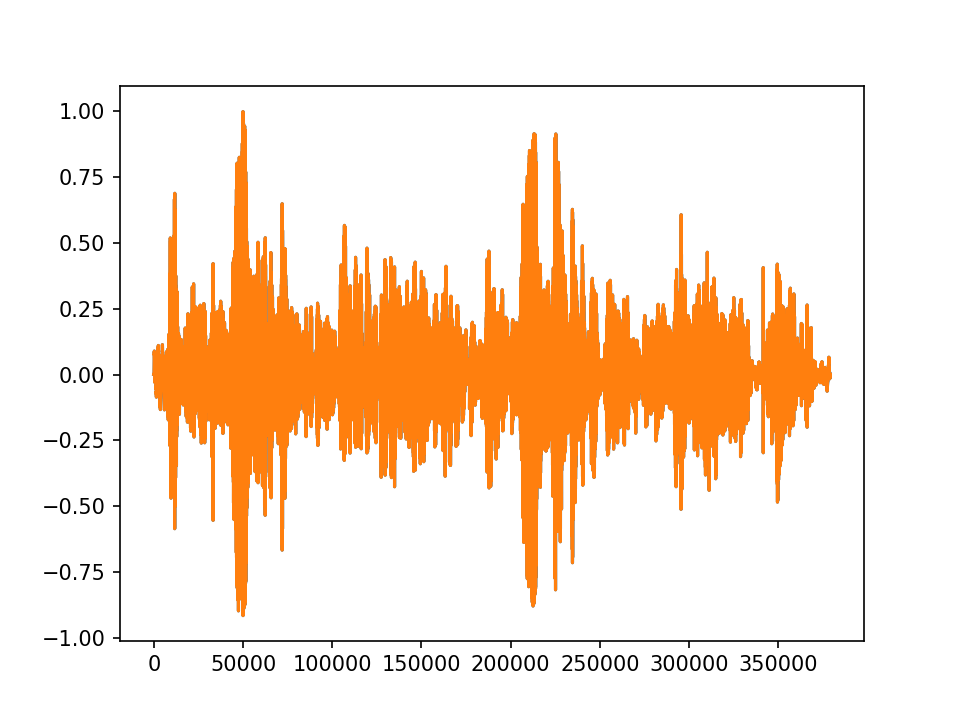

In [6]:
hn_1 = np.zeros(24)
hn_1[23] = 1
yn_1 = np.convolve(xn1, hn_1)
n = np.arange(len(yn_1))

fig, ax = plt.subplots()
ax.plot(n, yn_1, label='yn1')
ax.plot(k_1, xn1, label='xn1')

In [25]:
hn_1 = np.zeros(24)
hn_1[23] = 1
yn_1 = np.convolve(xn1, hn_1)


indices_1 = list(range(0, len(xn2)))
yn_1 = yn_1[indices_1]
vn_1 = yn_1 + xn2

hn_2 = np.zeros(20)
hn_2[19] = 1
yn_2 = np.convolve(xn2, hn_2)

indices_2 = list(range(0, len(xn1)))
yn_2 = yn_2[indices_2]
vn_2 = yn_2 + xn1

Audio(vn_2, rate=fs)

<IPython.core.display.Javascript object>


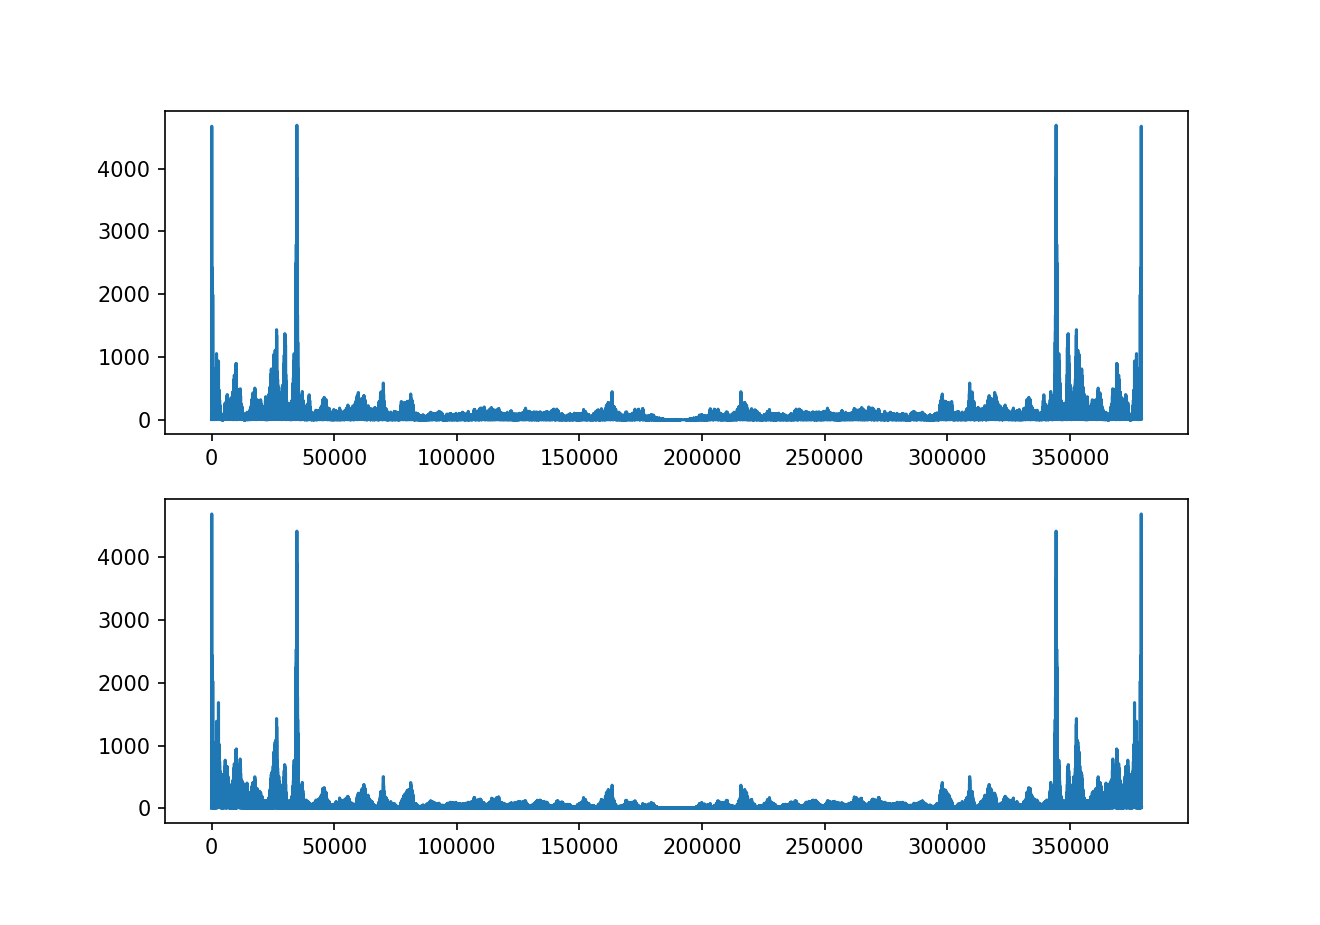

In [26]:
Vm_1 = fft(vn_1)
n_v1 = np.arange(len(vn_1))

Vm_2 = fft(vn_2)
n_v2 = np.arange(len(vn_2))

plt.close(5); plt.figure(5)
plt.subplot(2,1,1)
plt.plot(n_v1, np.abs(Vm_1))

plt.subplot(2,1,2)
plt.plot(n_v2, np.abs(Vm_2))

<IPython.core.display.Javascript object>


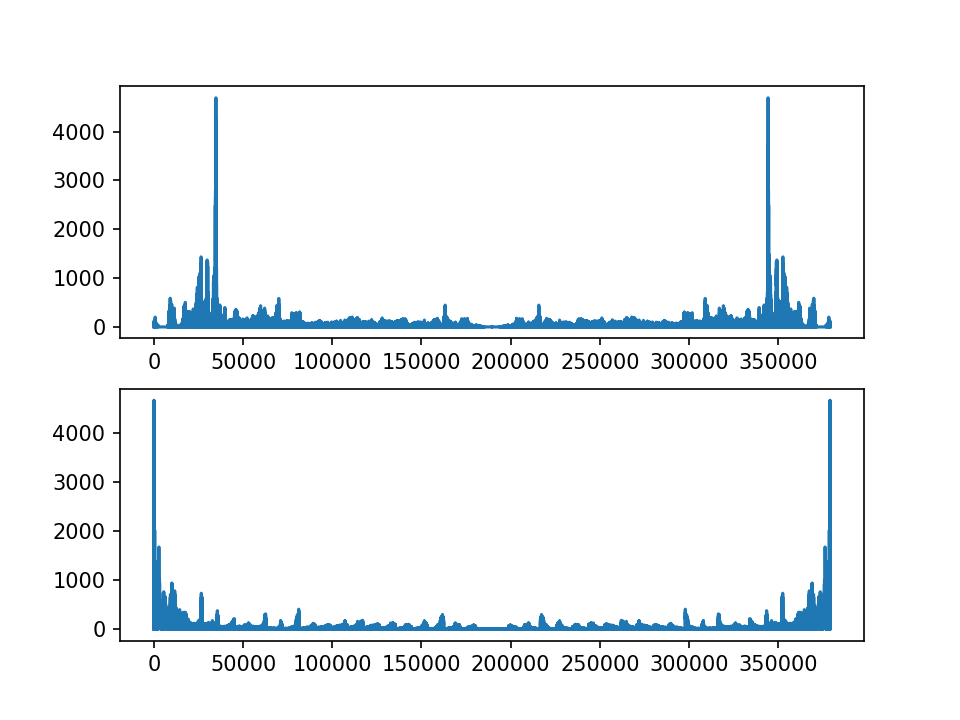

In [58]:
Sm_1 = []
Sm_2 = []

for x in range(len(Vm_1)):
    if np.abs(Vm_1[x]) > np.abs(Vm_2[x]):
        Sm_1.insert(x, Vm_1[x])
    else:
        Sm_1.insert(x, 0)
    if np.abs(Vm_2[x]) > np.abs(Vm_1[x]):
        Sm_2.insert(x, Vm_2[x])
    else:
        Sm_2.insert(x, 0)
        
plt.close(6); plt.figure(6)
plt.subplot(2,1,1)
plt.plot(np.arange(len(Sm_1)), np.abs(Sm_1))

plt.subplot(2,1,2)
plt.plot(np.arange(len(Sm_2)), np.abs(Sm_2))

<IPython.core.display.Javascript object>


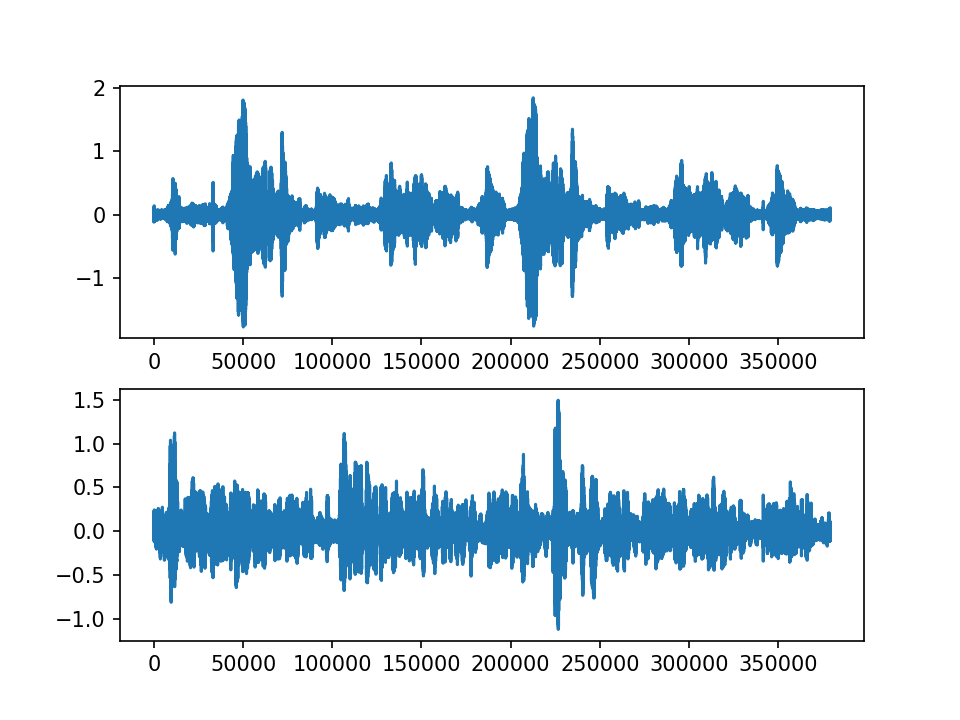

C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


In [84]:
sn_1 = ifft(Sm_1)
sn_2 = ifft(Sm_2)

plt.close(7); plt.figure(7)
plt.subplot(2,1,1)
plt.plot(np.arange(len(sn_1)), sn_1)

plt.subplot(2,1,2)
plt.plot(np.arange(len(sn_2)), sn_2)

In [67]:
Audio(sn_2, rate=fs)

In [102]:
data_1 = sn_1*0x8000
data_2 = sn_2*0x8000
wavfile.write('sn1(baby).wav', fs, data_1.astype(data.T[0].dtype))
wavfile.write('sn2(teacher).wav', fs, data_2.astype(data.T[1].dtype))

<ipython-input-102-cb4f4d1b41c5>:3: ComplexWarning: Casting complex values to real discards the imaginary part
  wavfile.write('sn1(baby).wav', fs, data_1.astype(data.T[0].dtype))
<ipython-input-102-cb4f4d1b41c5>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  wavfile.write('sn2(teacher).wav', fs, data_2.astype(data.T[1].dtype))
